# Proyek Akhir: Analisis Preferensi Belanja Online vs. Offline Berbasis AI
**Kelompok :** 3   
**Anggota 1 :** Syarifah Nesia (2024091017) - TEKNIK SIPIL   
**Anggota 2 :** Panji Kurnia Akbar (2024081024) - SISTEM INFORMASI    
**Mata Kuliah:** Introduction to AI

## 1. Import Library
Langkah pertama adalah memuat pustaka (*library*) eksternal Python yang esensial untuk pemrosesan struktur data tabel, analisis visual, manipulasi matriks, serta pemodelan prediktif algoritma kecerdasan buatan.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pustaka Pendukung Preprocessing, Validasi Silang, & Matriks Evaluasi
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             confusion_matrix, classification_report, roc_curve, auc)

# Algoritma Klasifikasi Supervised Learning (Sesuai Materi Kuliah)
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

## 2. Konfigurasi Global
Mengatur konfigurasi visualisasi grafik secara global agar menghasilkan gambar dengan resolusi tinggi (DPI 150), menyetel palet warna yang seragam, serta mengabaikan pesan peringatan (*warnings*) agar output notebook tetap bersih.

In [2]:
import warnings
warnings.filterwarnings('ignore')

# Set resolusi grafik tinggi untuk kebutuhan dokumen laporan
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 150

# Menentukan tema visualisasi dasar
sns.set_theme(style="whitegrid", palette="tab10")

## 3. Load Dataset
Memuat berkas data mentah (*raw data*) format CSV hasil penyebaran kuesioner Google Form ke dalam bentuk data frame menggunakan fungsi dari pustaka `pandas`.

In [3]:
# Nama file database asli sesuai form responses
nama_file_dataset = 'Survei Perilaku Konsumen_ Analisis Preferensi Belanja Online vs. Offline Berbasis AI.csv'

# Memuat data
df_raw = pd.read_csv(nama_file_dataset)

print(f"Log Sukses: Berhasil membaca data kuesioner sebanyak {df_raw.shape[0]} baris.")

Log Sukses: Berhasil membaca data kuesioner sebanyak 101 baris.


## 4. Data Cleaning
Proses pembersihan data dilakukan dengan menyamakan nama kolom pertanyaan yang sangat panjang menjadi variabel teknis pendek agar penulisan kode lebih ringkas (*Clean Code*). Kolom identifier acak seperti `Timestamp` dan `Nama Lengkap` juga dihapus karena berperan sebagai *noise*.

In [4]:
df_clean = df_raw.copy()

# Pemetaan nama variabel kolom pendek
kolom_teknis = [
    'Timestamp', 'Nama', 'Gender', 'Usia', 'Pekerjaan', 'Pengeluaran',
    'Freq_Online', 'Kategori_Online', 'Faktor_Online', 'Pengaruh_Review',
    'Alasan_Offline', 'Khawatir_Penipuan', 'Harga_Murah_Online',
    'Waktu_Tunggu', 'Penting_Interaksi_SPG', 'Target_Platform'
]
df_clean.columns = kolom_teknis

# Mengeliminasi fitur non-prediktif (Noise Removal)
df_clean = df_clean.drop(columns=['Timestamp', 'Nama'])

print("Proses pembersihan kolom selesai.")

Proses pembersihan kolom selesai.


## 5. Audit Struktur Data
Melakukan pengecekan menyeluruh terhadap tipe data setiap kolom, memeriksa dimensi bentuk data, serta mendeteksi keberadaan nilai kosong (*missing values*) untuk memastikan kualitas data siap dimodelkan.

In [5]:
print("=== RINGKASAN DATA FRAME INFO ===")
df_clean.info()

print("\n=== DETAIL AUDIT NILAI KOSONG ===")
tabel_audit_kosong = pd.DataFrame({
    'Jumlah Missing': df_clean.isnull().sum(),
    'Persentase (%)': (df_clean.isnull().sum() / len(df_clean)) * 100
})
display(tabel_audit_kosong)

=== RINGKASAN DATA FRAME INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Gender                 101 non-null    str  
 1   Usia                   101 non-null    str  
 2   Pekerjaan              101 non-null    str  
 3   Pengeluaran            101 non-null    str  
 4   Freq_Online            101 non-null    int64
 5   Kategori_Online        101 non-null    str  
 6   Faktor_Online          101 non-null    str  
 7   Pengaruh_Review        101 non-null    int64
 8   Alasan_Offline         101 non-null    str  
 9   Khawatir_Penipuan      101 non-null    int64
 10  Harga_Murah_Online     101 non-null    int64
 11  Waktu_Tunggu           101 non-null    str  
 12  Penting_Interaksi_SPG  101 non-null    int64
 13  Target_Platform        101 non-null    str  
dtypes: int64(5), str(9)
memory usage: 11.2 KB

=== DETAIL AUDIT NILAI K

,Jumlah Missing,Persentase (%)
Gender,0,0.0
Usia,0,0.0
Pekerjaan,0,0.0
Pengeluaran,0,0.0
Freq_Online,0,0.0
Kategori_Online,0,0.0
Faktor_Online,0,0.0
Pengaruh_Review,0,0.0
Alasan_Offline,0,0.0
Khawatir_Penipuan,0,0.0


## 6. Exploratory Data Analysis (EDA)
Fase eksplorasi visual secara terpisah untuk menggali wawasan pola perilaku dari data kuesioner responden belanja masyarakat.

### 6.1 Distribusi Kelas Target (Visualisasi Pie Chart)
Visualisasi Pie Chart (Diagram Lingkaran) untuk meninjau proporsi persentase distribusi data pada variabel label target utama (`Target_Platform`).

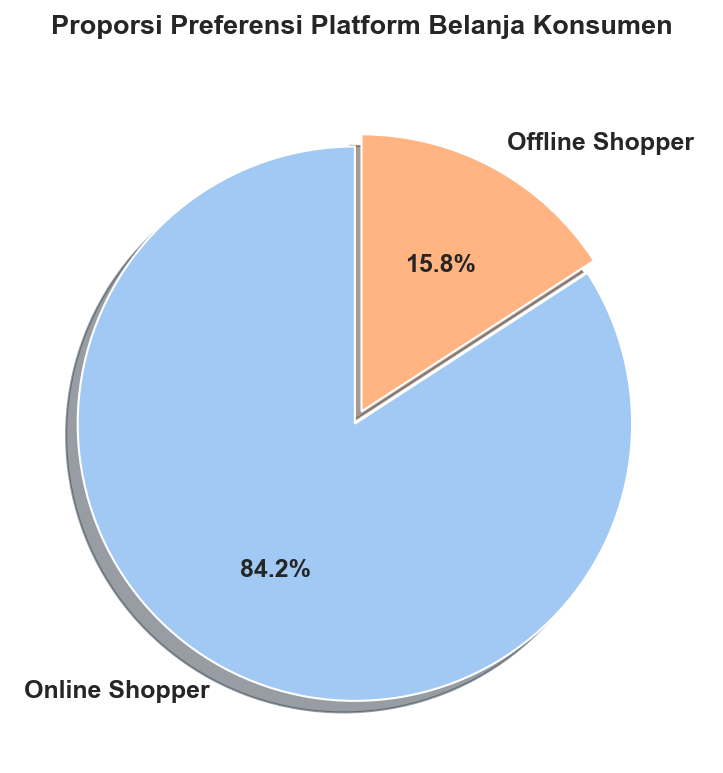

In [6]:
plt.figure(figsize=(6, 6))

# Menyiapkan data hitungan dan palet warna
target_counts = df_clean['Target_Platform'].value_counts()
warna_pie = sns.color_palette('pastel')[0:2]

# Plotting Pie Chart dengan efek shadow dan potongan terpisah
plt.pie(target_counts, labels=target_counts.index, autopct='%1.1f%%', 
        colors=warna_pie, startangle=90, explode=(0.05, 0), shadow=True, 
        textprops={'fontsize': 12, 'weight': 'bold'})

plt.title('Proporsi Preferensi Platform Belanja Konsumen', fontsize=13, fontweight='bold', pad=15)
plt.show()

### 6.2 Analisis Hubungan Gender Terhadap Pilihan Platform Belanja
Diagram komparasi untuk melihat kecenderungan pemilihan platform belanja berdasarkan jenis kelamin responden perempuan dan laki-laki.

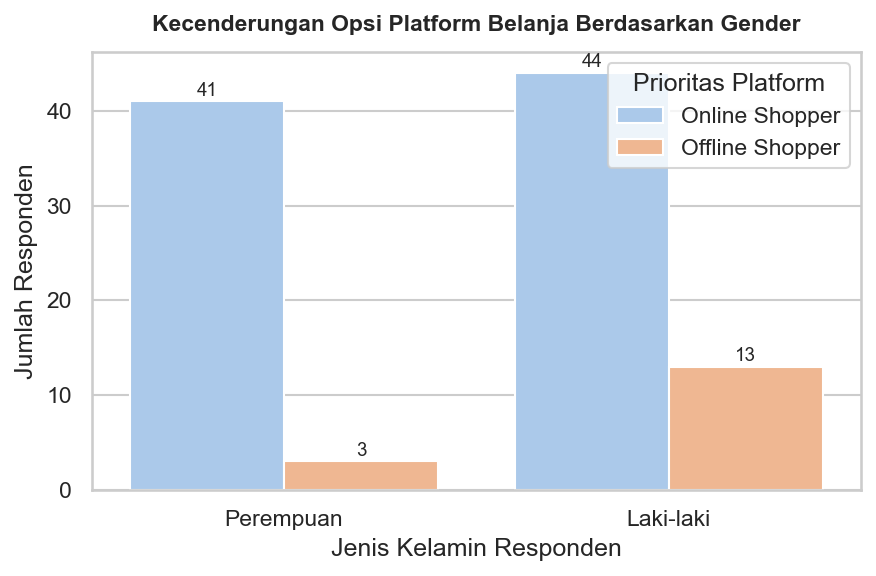

In [7]:
plt.figure(figsize=(6, 4))
plot_gender = sns.countplot(data=df_clean, x='Gender', hue='Target_Platform', palette='pastel')

plt.title('Kecenderungan Opsi Platform Belanja Berdasarkan Gender', fontsize=11, fontweight='bold', pad=10)
plt.xlabel('Jenis Kelamin Responden')
plt.ylabel('Jumlah Responden')
plt.legend(title='Prioritas Platform')

for p in plot_gender.patches:
    if p.get_height() > 0:
        plot_gender.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                             ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=9)
plt.tight_layout()
plt.show()

### 6.3 Analisis Kelompok Usia Terhadap Preferensi Platform Belanja
Diagram untuk memetakan bagaimana faktor rentang batasan umur memengaruhi keputusan kelompok konsumen dalam berbelanja.

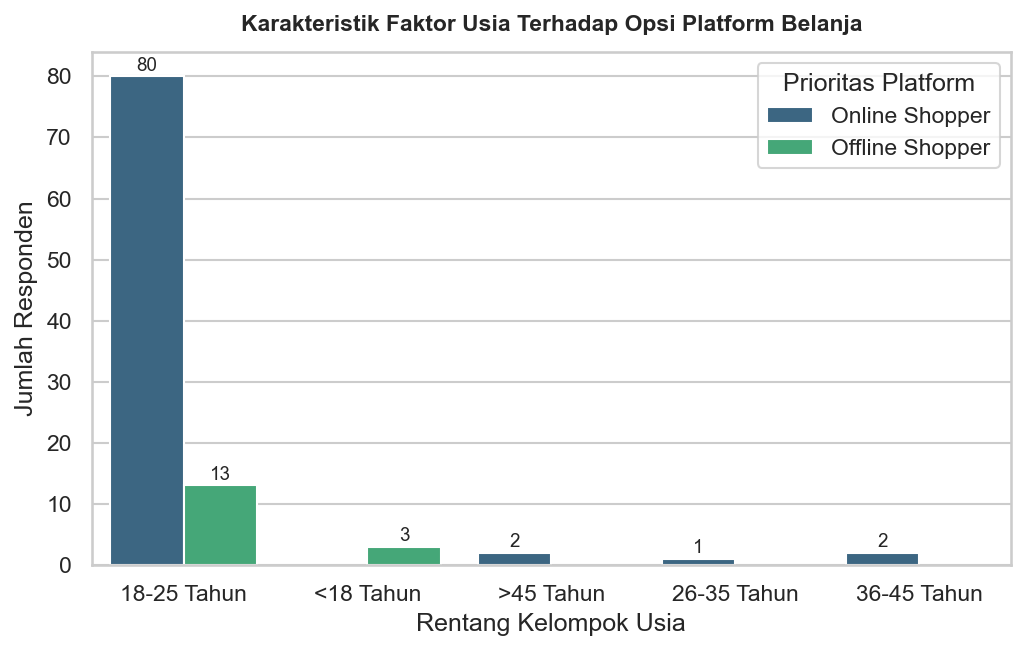

In [8]:
plt.figure(figsize=(7, 4.5))
plot_usia = sns.countplot(data=df_clean, x='Usia', hue='Target_Platform', palette='viridis')

plt.title('Karakteristik Faktor Usia Terhadap Opsi Platform Belanja', fontsize=11, fontweight='bold', pad=10)
plt.xlabel('Rentang Kelompok Usia')
plt.ylabel('Jumlah Responden')
plt.legend(title='Prioritas Platform')

for p in plot_usia.patches:
    if p.get_height() > 0:
        plot_usia.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                             ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=9)
plt.tight_layout()
plt.show()

### 6.4 Pengaruh Tingkat Pengeluaran Bulanan Terhadap Pilihan Belanja
Visualisasi grafik silang guna menganalisis korelasi status kelas ekonomi pengeluaran bulanan terhadap kecenderungan berbelanja.

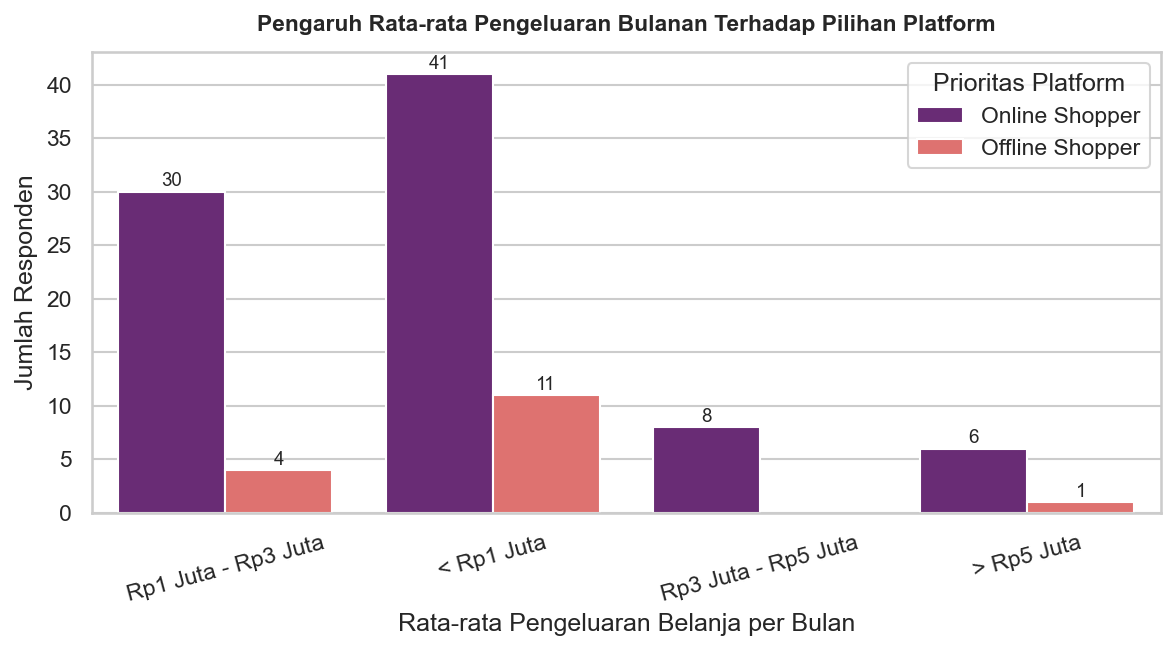

In [9]:
plt.figure(figsize=(8, 4.5))
plot_pengeluaran = sns.countplot(data=df_clean, x='Pengeluaran', hue='Target_Platform', palette='magma')

plt.title('Pengaruh Rata-rata Pengeluaran Bulanan Terhadap Pilihan Platform', fontsize=11, fontweight='bold', pad=10)
plt.xlabel('Rata-rata Pengeluaran Belanja per Bulan')
plt.ylabel('Jumlah Responden')
plt.xticks(rotation=15)
plt.legend(title='Prioritas Platform')

for p in plot_pengeluaran.patches:
    if p.get_height() > 0:
        plot_pengeluaran.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                             ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=9)
plt.tight_layout()
plt.show()

### 6.5 Matriks Korelasi Nilai Atribut Berbasis Skala Ordinal Numerik
Visualisasi peta panas (Correlation Heatmap) untuk mendeteksi kekuatan hubungan linear antar kolom kuantitatif kuesioner.

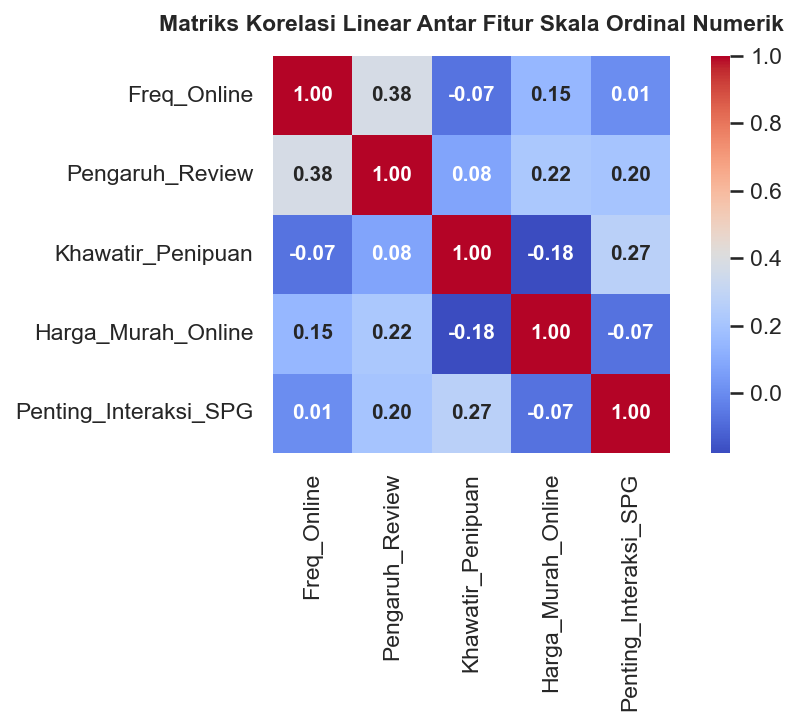

In [10]:
plt.figure(figsize=(7, 5))
kolom_numerik = ['Freq_Online', 'Pengaruh_Review', 'Khawatir_Penipuan', 'Harga_Murah_Online', 'Penting_Interaksi_SPG']
matriks_korelasi = df_clean[kolom_numerik].corr()

sns.heatmap(matriks_korelasi, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True,
            annot_kws={"size": 10, "weight": "bold"})

plt.title('Matriks Korelasi Linear Antar Fitur Skala Ordinal Numerik', fontsize=11, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

## 7. Feature Engineering (Transformasi Variabel Teks Kategorikal)
Mengubah data berbasis teks kategorikal menjadi representasi matriks angka agar dapat dibaca oleh persamaan matematika komputer. Kita menerapkan `LabelEncoder` pada variabel target dan mengekstraksi seluruh fitur pendukung berbasis teks kategorikal menjadi kolom biner angka menggunakan skema *One-Hot Encoding*.

In [11]:
X = df_clean.drop(columns=['Target_Platform'])
y = df_clean['Target_Platform']

# Encoding label target (Online Shopper -> 1, Offline Shopper -> 0)
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

# One-Hot Encoding fitur teks penunjang
X_encoded = pd.get_dummies(X, drop_first=True)

print(f"Total dimensi kolom fitur setelah rekayasa encoding: {X_encoded.shape[1]} kolom atribut.")

Total dimensi kolom fitur setelah rekayasa encoding: 39 kolom atribut.


## 8. Preprocessing & Split Data
Membagi data frame ke dalam porsi Data Latihan (80%) dan Data Pengujian (20%). Pembagian ini menggunakan parameter stratifikasi (`stratify`) agar proporsi sebaran kelas target tetap seimbang di kedua partisi data.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Sampel Data Latihan : {X_train.shape[0]} baris")
print(f"Sampel Data Uji     : {X_test.shape[0]} baris")

Sampel Data Latihan : 80 baris
Sampel Data Uji     : 21 baris


## 9. Feature Scaling
Melakukan penyamaan skala rentang nilai data fitur (*Z-score Standardization*) menggunakan objek `StandardScaler` agar algoritma AI berbasis perhitungan matriks jarak dapat memproses data secara seimbang dan stabil.

In [13]:
scaler_z = StandardScaler()
X_train_scaled = scaler_z.fit_transform(X_train)
X_test_scaled = scaler_z.transform(X_test)

print("Proses standardisasi skala fitur selesai diaplikasikan.")

Proses standardisasi skala fitur selesai diaplikasikan.


## 10. Model Training
Menginisialisasi objek arsitektur serta parameter internal dari tiga algoritma AI: Naive Bayes, Logistic Regression, dan K-Nearest Neighbors. Dilanjutkan dengan proses pelatihan menggunakan pasangan data latih skala standar secara paralel.

In [14]:
kamus_model_ai = {
    "Naive Bayes (Gaussian Classifier)": GaussianNB(),
    "Logistic Regression (Sigmoid Bound)": LogisticRegression(random_state=42, max_iter=2000),
    "K-Nearest Neighbors (KNN, K=5)": KNeighborsClassifier(n_neighbors=5)
}

hasil_prediksi_uji = {}
hasil_probabilitas_uji = {}

# Training loop
for nama_model, objek_model in kamus_model_ai.items():
    objek_model.fit(X_train_scaled, y_train)
    hasil_prediksi_uji[nama_model] = objek_model.predict(X_test_scaled)
    hasil_probabilitas_uji[nama_model] = objek_model.predict_proba(X_test_scaled)[:, 1]

print("✔ Status Sukses: Tiga arsitektur algoritma AI telah dilatih sepenuhnya.")

✔ Status Sukses: Tiga arsitektur algoritma AI telah dilatih sepenuhnya.


## 11. 5-Fold Stratified Cross Validation
Melakukan uji validasi silang acak berlapis sebanyak 5 putaran (*5-Fold*) secara langsung pada data latihan untuk menguji konsistensi dan stabilitas keandalan akurasi tebakan model sebelum dihadapkan pada data pengujian luar.

In [15]:
print("=== HASIL EVALUASI KONSISTENSI 5-FOLD CROSS VALIDATION ===")
for nama_model, objek_model in kamus_model_ai.items():
    skor_cv = cross_val_score(objek_model, X_train_scaled, y_train, cv=StratifiedKFold(5), scoring='accuracy')
    print(f"{nama_model} ➔ Rata-rata Akurasi CV: {skor_cv.mean():.2%} (Standar Deviasi: {skor_cv.std():.4f})")

=== HASIL EVALUASI KONSISTENSI 5-FOLD CROSS VALIDATION ===
Naive Bayes (Gaussian Classifier) ➔ Rata-rata Akurasi CV: 70.00% (Standar Deviasi: 0.0729)
Logistic Regression (Sigmoid Bound) ➔ Rata-rata Akurasi CV: 80.00% (Standar Deviasi: 0.0729)
K-Nearest Neighbors (KNN, K=5) ➔ Rata-rata Akurasi CV: 82.50% (Standar Deviasi: 0.0468)


## 12. Evaluasi Model Menggunakan Confusion Matrix
Meninjau peta persebaran letak kesalahan tebakan sistem terhadap kategori kelas pembelanja melalui visualisasi matriks konfusi secara terpisah per model.

### 12.1 Confusion Matrix: Naive Bayes (Gaussian Classifier)

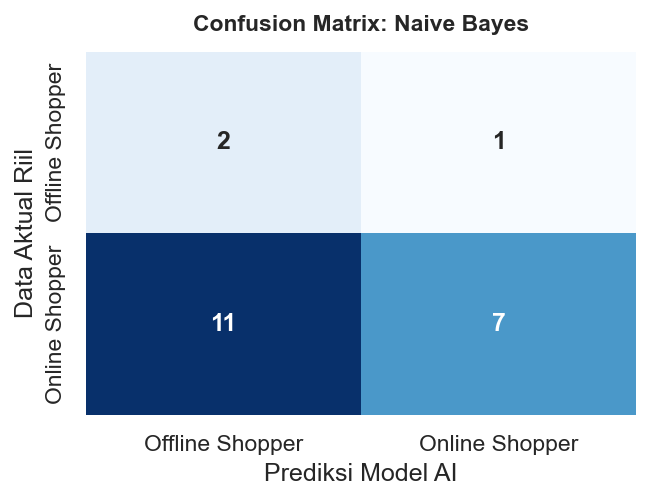

In [16]:
plt.figure(figsize=(4.5, 3.5))
cm_nb = confusion_matrix(y_test, hasil_prediksi_uji["Naive Bayes (Gaussian Classifier)"])

sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=le_target.classes_, yticklabels=le_target.classes_,
            annot_kws={"size": 12, "weight": "bold"})

plt.title('Confusion Matrix: Naive Bayes', fontsize=11, fontweight='bold', pad=10)
plt.xlabel('Prediksi Model AI')
plt.ylabel('Data Aktual Riil')
plt.tight_layout()
plt.show()

### 12.2 Confusion Matrix: Logistic Regression (Sigmoid Bound)

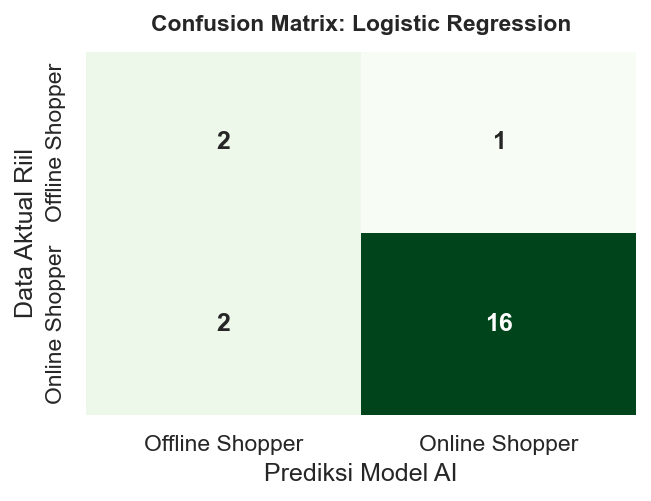

In [17]:
plt.figure(figsize=(4.5, 3.5))
cm_lr = confusion_matrix(y_test, hasil_prediksi_uji["Logistic Regression (Sigmoid Bound)"])

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=le_target.classes_, yticklabels=le_target.classes_,
            annot_kws={"size": 12, "weight": "bold"})

plt.title('Confusion Matrix: Logistic Regression', fontsize=11, fontweight='bold', pad=10)
plt.xlabel('Prediksi Model AI')
plt.ylabel('Data Aktual Riil')
plt.tight_layout()
plt.show()

### 12.3 Confusion Matrix: K-Nearest Neighbors (KNN, K=5)

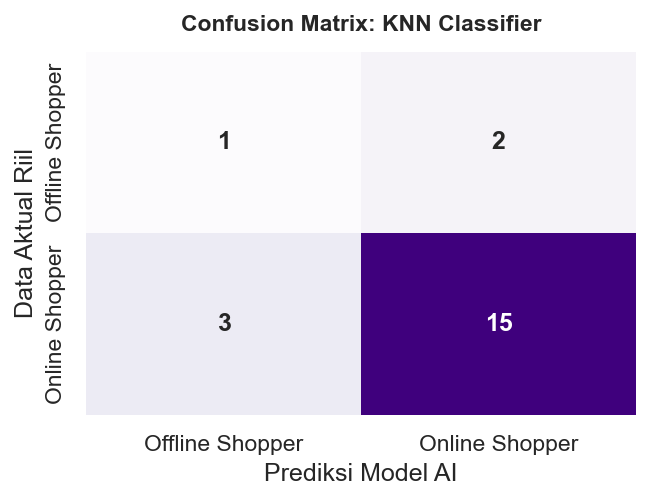

In [18]:
plt.figure(figsize=(4.5, 3.5))
cm_knn = confusion_matrix(y_test, hasil_prediksi_uji["K-Nearest Neighbors (KNN, K=5)"])

sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=le_target.classes_, yticklabels=le_target.classes_,
            annot_kws={"size": 12, "weight": "bold"})

plt.title('Confusion Matrix: KNN Classifier', fontsize=11, fontweight='bold', pad=10)
plt.xlabel('Prediksi Model AI')
plt.ylabel('Data Aktual Riil')
plt.tight_layout()
plt.show()

## 13. Perbandingan Akhir Efektivitas Hasil Kinerja Algoritma AI
Tahap akhir komparasi performa model komprehensif. Menghitung akumulasi parameter (*Accuracy, Precision, Recall, F1-Score*), menggambarkan **Kurva ROC** beserta penghitungan nilai **AUC**, serta menyusun ringkasan ke dalam format tabel resmi berfitur penanganan rintangan pengecualian (*exception handling*).

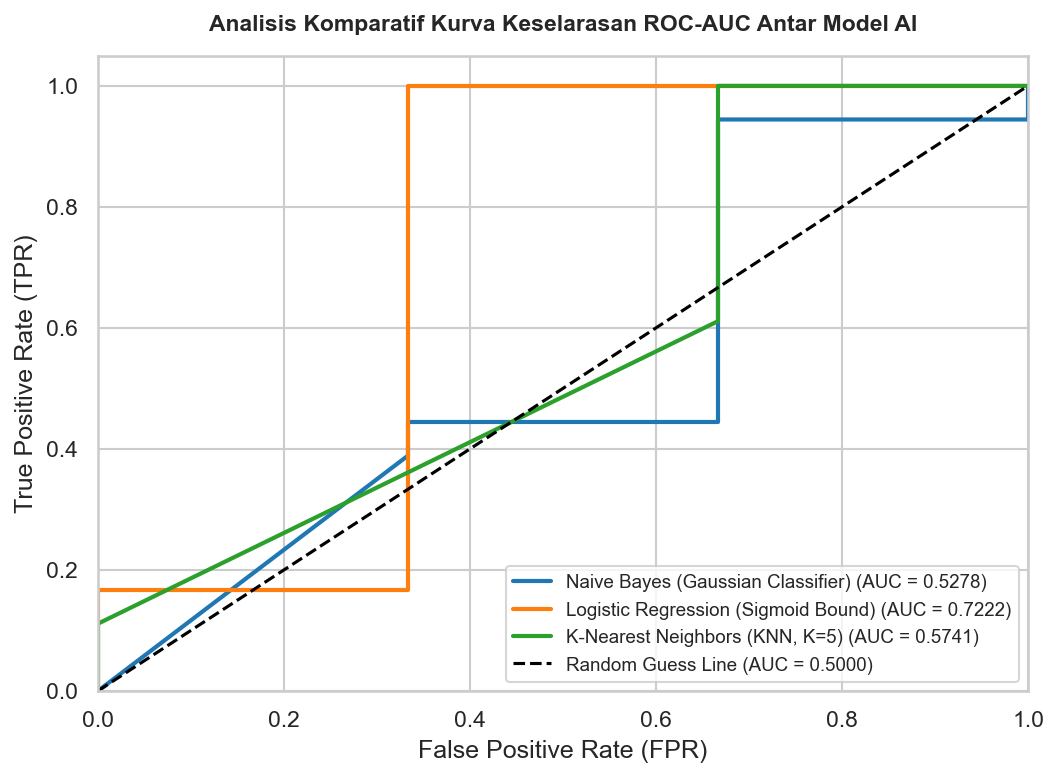


============================= TABEL RINGKASAN KOMPARASI METRIK EVALUASI MODEL AI =============================


,Model Algoritma AI,Accuracy (Akurasi),Precision (Presisi),Recall (Sensitivitas),F1-Score,ROC-AUC Score
0,Naive Bayes (Gaussian Classifier),42.86%,77.20%,42.86%,49.73%,0.5278
1,Logistic Regression (Sigmoid Bound),85.71%,87.82%,85.71%,86.53%,0.7222
2,"K-Nearest Neighbors (KNN, K=5)",76.19%,79.20%,76.19%,77.55%,0.5741



[REPORT TEXT] Rincian Metrik Klasifikasi Komprehensif - Naive Bayes (Gaussian Classifier):
                 precision    recall  f1-score   support

Offline Shopper       0.15      0.67      0.25         3
 Online Shopper       0.88      0.39      0.54        18

       accuracy                           0.43        21
      macro avg       0.51      0.53      0.39        21
   weighted avg       0.77      0.43      0.50        21

---------------------------------------------------------------------------

[REPORT TEXT] Rincian Metrik Klasifikasi Komprehensif - Logistic Regression (Sigmoid Bound):
                 precision    recall  f1-score   support

Offline Shopper       0.50      0.67      0.57         3
 Online Shopper       0.94      0.89      0.91        18

       accuracy                           0.86        21
      macro avg       0.72      0.78      0.74        21
   weighted avg       0.88      0.86      0.87        21

------------------------------------------------

In [19]:
list_perbandingan_performa = []

plt.figure(figsize=(8, 5.5))

# Perhitungan nilai performa tingkat lanjut dan plotting kurva ROC
for nama_model, y_pred in hasil_prediksi_uji.items():
    y_prob = hasil_probabilitas_uji[nama_model]
    
    skor_accuracy = accuracy_score(y_test, y_pred)
    skor_precision = precision_score(y_test, y_pred, average='weighted')
    skor_recall = recall_score(y_test, y_pred, average='weighted')
    skor_f1 = f1_score(y_test, y_pred, average='weighted')
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    skor_auc = auc(fpr, tpr)
    
    list_perbandingan_performa.append({
        'Model Algoritma AI': nama_model,
        'Accuracy (Akurasi)': skor_accuracy,
        'Precision (Presisi)': skor_precision,
        'Recall (Sensitivitas)': skor_recall,
        'F1-Score': skor_f1,
        'ROC-AUC Score': skor_auc
    })
    
    plt.plot(fpr, tpr, label=f'{nama_model} (AUC = {skor_auc:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess Line (AUC = 0.5000)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('Analisis Komparatif Kurva Keselarasan ROC-AUC Antar Model AI', fontsize=11, fontweight='bold', pad=12)
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc="lower right", fontsize=9)
plt.show()

df_summary_final = pd.DataFrame(list_perbandingan_performa)

print("\n" + "="*29 + " TABEL RINGKASAN KOMPARASI METRIK EVALUASI MODEL AI " + "="*29)

try:
    display(df_summary_final.style.format({
        'Accuracy (Akurasi)': '{:.2%}',
        'Precision (Presisi)': '{:.2%}',
        'Recall (Sensitivitas)': '{:.2%}',
        'F1-Score': '{:.2%}',
        'ROC-AUC Score': '{:.4f}'
    }).highlight_max(axis=0, color='lightgreen', subset=['Accuracy (Akurasi)', 'F1-Score', 'ROC-AUC Score']))
except AttributeError:
    print("(Format penanda warna tidak aktif karena library 'jinja2' belum siap)\n")
    display(df_summary_final)
    
print("=" * 110)

for nama_model, y_pred in hasil_prediksi_uji.items():
    print(f"\n[REPORT TEXT] Rincian Metrik Klasifikasi Komprehensif - {nama_model}:")
    print(classification_report(y_test, y_pred, target_names=le_target.classes_))
    print("-" * 75)

## 14. Analisis Log Feature Probability (Feature Importance)
Langkah pamungkas ini divisualisasikan melalui **Horizontal Bar Chart** untuk mengidentifikasi atribut atau pertanyaan kuesioner mana yang memiliki pembobotan *Log-Odds Probability* tertinggi dalam mendorong keputusan seorang konsumen untuk memilih platform belanja online.

### 14.1 Top 10 Faktor Pendorong Utama: ONLINE SHOPPER
Fitur-fitur di bawah ini memiliki nilai koefisien *Logistic Regression* positif tertinggi. Semakin besar nilainya, semakin fitur tersebut mendorong konsumen untuk memilih platform belanja digital.

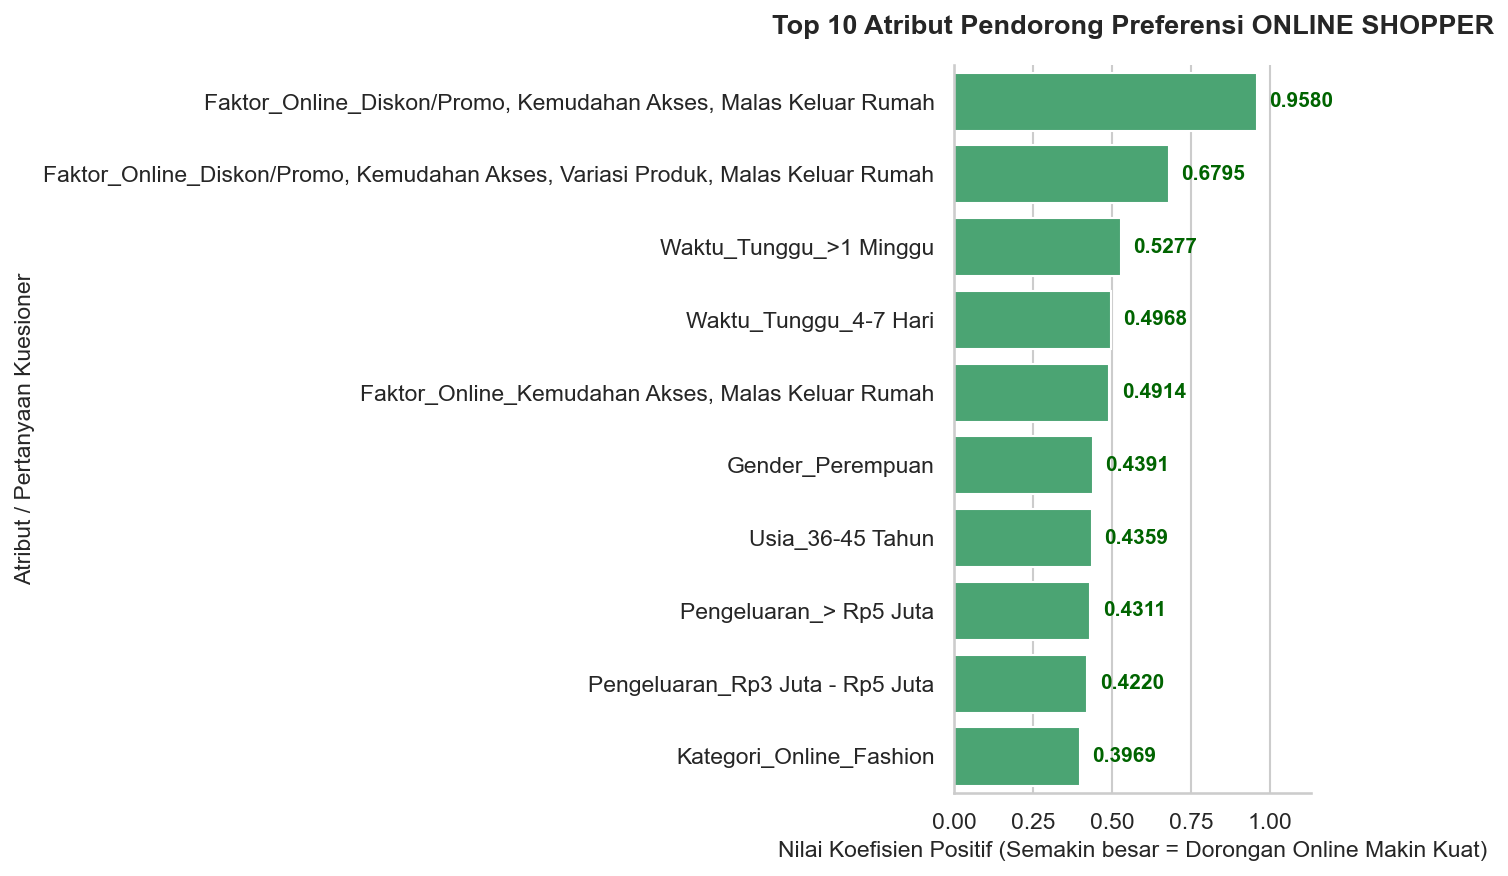

In [20]:
# Mengekstraksi nilai koefisien dan nama fitur dari model Logistic Regression
model_logreg = kamus_model_ai["Logistic Regression (Sigmoid Bound)"]
feat_names = X_encoded.columns
coefs = model_logreg.coef_[0]

# Mengubahnya menjadi struktur data Pandas Series
feat_df = pd.Series(coefs, index=feat_names)

# Mengambil Top 10 fitur positif (Pendorong Online)
top_online = feat_df.nlargest(10)

# Visualisasi 14.1 - Pendorong Online Shopper
plt.figure(figsize=(9, 6))
ax1 = sns.barplot(x=top_online.values, y=top_online.index, color='mediumseagreen')

# Menambahkan label angka presisi di ujung setiap batang
ax1.bar_label(ax1.containers[0], fmt='%.4f', padding=6, fontsize=10, fontweight='bold', color='darkgreen')

plt.title('Top 10 Atribut Pendorong Preferensi ONLINE SHOPPER', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Nilai Koefisien Positif (Semakin besar = Dorongan Online Makin Kuat)', fontsize=11)
plt.ylabel('Atribut / Pertanyaan Kuesioner', fontsize=11)

# Estetika: Menghilangkan garis tepi atas dan kanan
sns.despine(top=True, right=True)

# Memperluas margin sumbu X agar teks angka tidak terpotong
plt.xlim(0, top_online.max() * 1.18)

plt.tight_layout()
plt.show()

### 14.2 Top 10 Faktor Pendorong Utama: OFFLINE SHOPPER
Fitur-fitur di bawah ini memiliki nilai koefisien negatif paling kuat. Untuk mempermudah pembacaan visual, nilai tersebut diabsolutkan (mutlak). Semakin panjang batangnya, semakin kuat faktor tersebut menahan konsumen untuk tetap berbelanja di toko fisik.

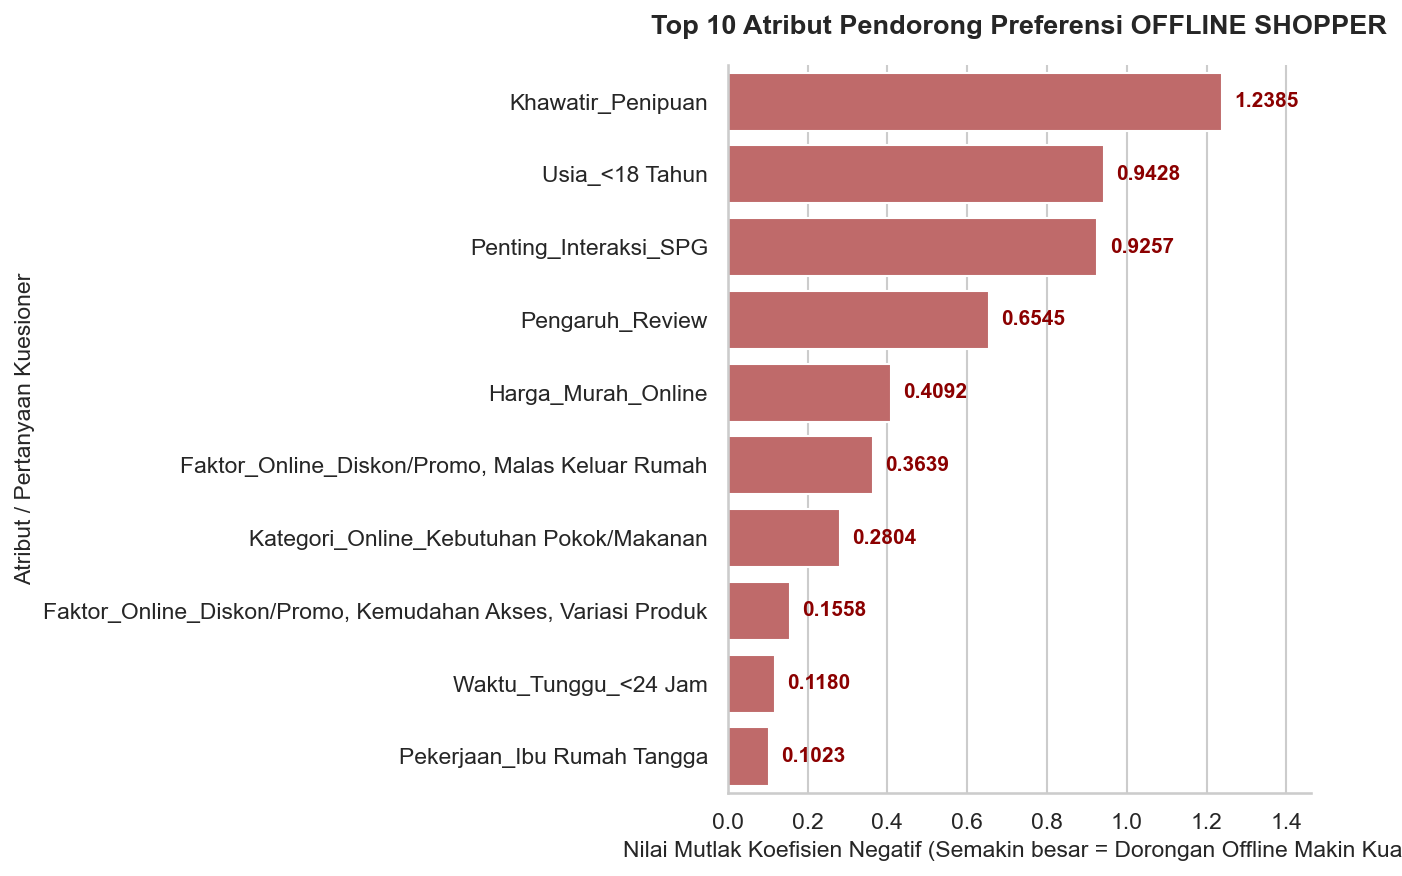

In [21]:
# Mengambil Top 10 fitur negatif (Pendorong Offline)
top_offline = feat_df.nsmallest(10)

# Visualisasi 14.2 - Pendorong Offline Shopper
plt.figure(figsize=(9, 6))
# Menggunakan nilai absolut (.abs()) agar batang mengarah ke kanan secara normal
ax2 = sns.barplot(x=top_offline.abs().values, y=top_offline.index, color='indianred')

# Menambahkan label angka presisi di ujung setiap batang
ax2.bar_label(ax2.containers[0], fmt='%.4f', padding=6, fontsize=10, fontweight='bold', color='darkred')

plt.title('Top 10 Atribut Pendorong Preferensi OFFLINE SHOPPER', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Nilai Mutlak Koefisien Negatif (Semakin besar = Dorongan Offline Makin Kuat)', fontsize=11)
plt.ylabel('Atribut / Pertanyaan Kuesioner', fontsize=11)

# Estetika: Menghilangkan garis tepi atas dan kanan
sns.despine(top=True, right=True)

# Memperluas margin sumbu X agar teks angka tidak terpotong
plt.xlim(0, top_offline.abs().max() * 1.18)

plt.tight_layout()
plt.show()